## Temporal Autocorrelation of SAE Features

**Goal**: Validate that "slow-moving" features exist in SAE-recovered representations of GPT-2 Small.
Specifically, do features with high temporal autocorrelation and low activation magnitude exist?

See `docs/bill/experiments/sae_autocorrelations/experiment_design.md` for full design.

In [1]:
import numpy as np
import torch
from tqdm import tqdm

from bill.temporal_autocorrelation.config import ExperimentConfig
from bill.temporal_autocorrelation.data import load_tokenized_sequences
from bill.temporal_autocorrelation.activations import load_model_and_sae, extract_sae_features_batch
from bill.temporal_autocorrelation.statistics import FeatureStatistics, compute_shuffled_baseline, ljung_box_test
from bill.temporal_autocorrelation.visualization import (
    plot_magnitude_vs_autocorrelation,
    plot_autocorrelation_histogram,
    plot_autocorrelation_decay,
    plot_token_activation_heatmap,
    plot_ljung_box_pvalues,
)

## Configuration

For a quick smoke test, set `num_sequences=8, batch_size=4`.
For the full experiment, use the defaults (4096 sequences of length 128, batch size 16).

In [2]:
config = ExperimentConfig(
    # num_sequences=8,  # uncomment for smoke test
    # batch_size=4,
)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print(f"Sequences: {config.num_sequences}, Batch size: {config.batch_size}")

Device: cpu
Sequences: 4096, Batch size: 16


## Load Model, SAE, and Data

In [3]:
model, sae = load_model_and_sae(config, device=device)
print(f"Model: {config.model_name}, SAE features: {sae.cfg.d_sae}")

`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model gpt2-small into HookedTransformer
Model: gpt2-small, SAE features: 24576


/Users/paullab/temp_xc/.venv/lib/python3.12/site-packages/sae_lens/saes/sae.py:251: UserWarning: 
This SAE has non-empty model_from_pretrained_kwargs. 
For optimal performance, load the model like so:
model = HookedSAETransformer.from_pretrained_no_processing(..., **cfg.model_from_pretrained_kwargs)
  warnings.warn(


In [4]:
tokens = load_tokenized_sequences(config, model)
print(f"Tokens shape: {tokens.shape}")

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Tokenizing: 100%|█████████▉| 4095/4096 [00:07<00:00, 518.73it/s]


Tokens shape: torch.Size([4096, 128])


## Sanity Check: SAE Reconstruction

Verify that the SAE reconstructs the residual stream reasonably well.

In [5]:
with torch.no_grad():
    sample = tokens[:1].to(device)
    _, cache = model.run_with_cache(sample, names_filter=config.hook_point)
    residuals = cache[config.hook_point]  # [1, T, d_model]
    encoded = sae.encode(residuals)
    reconstructed = sae.decode(encoded)
    
    mse = ((residuals - reconstructed) ** 2).mean().item()
    var = residuals.var().item()
    r2 = 1 - mse / var
    print(f"Reconstruction MSE: {mse:.4f}")
    print(f"Residual variance: {var:.4f}")
    print(f"R^2: {r2:.4f}")
    
    del cache, residuals, encoded, reconstructed
    if device == "cuda":
        torch.cuda.empty_cache()

Reconstruction MSE: 0.9563
Residual variance: 111.5958
R^2: 0.9914


## Extract Features and Accumulate Statistics

Process sequences in batches. For each batch:
1. Extract SAE features (post-ReLU)
2. Update incremental statistics (magnitude, frequency, autocorrelation)

We never materialize the full `[N, T, D]` tensor. Each batch is ~50MB of feature activations.

In [6]:
num_features = sae.cfg.d_sae
stats = FeatureStatistics(num_features=num_features, max_lag=config.max_lag)

# Track which sequence has the highest total activation per feature (for visualization later)
best_seq_idx = np.zeros(num_features, dtype=np.int64)
best_total_act = np.zeros(num_features)

num_batches = (config.num_sequences + config.batch_size - 1) // config.batch_size

for batch_idx in tqdm(range(num_batches), desc="Processing batches"):
    start = batch_idx * config.batch_size
    end = min(start + config.batch_size, config.num_sequences)
    batch_tokens = tokens[start:end].to(device)
    
    # Extract SAE features: [B, T, D]
    batch_acts = extract_sae_features_batch(model, sae, batch_tokens, config.hook_point)
    
    # Update stats per sequence
    for i in range(batch_acts.shape[0]):
        stats.update(batch_acts[i], min_activations=config.min_activations_for_autocorr)
    
    # Track best sequence per feature
    total_acts = batch_acts.sum(axis=1)  # [B, D]
    batch_best = total_acts.argmax(axis=0)  # [D]
    batch_best_vals = total_acts[batch_best, np.arange(num_features)]  # [D]
    improved = batch_best_vals > best_total_act
    best_total_act[improved] = batch_best_vals[improved]
    best_seq_idx[improved] = start + batch_best[improved]

stats.finalize()
print(f"Total positions processed: {stats.total_positions}")
print(f"Features with valid magnitude: {(~np.isnan(stats.mean_magnitude_when_active)).sum()}")
print(f"Features with valid lag-1 AC: {(~np.isnan(stats.mean_autocorrelation[:, 0])).sum()}")

Processing batches: 100%|██████████| 256/256 [04:41<00:00,  1.10s/it]

Total positions processed: 524288
Features with valid magnitude: 24570
Features with valid lag-1 AC: 24559


## Sanity Check: Sparsity

Median activation frequency should be well below 5%.

In [7]:
freq = stats.activation_frequency
print(f"Activation frequency — median: {np.median(freq):.4f}, mean: {freq.mean():.4f}, max: {freq.max():.4f}")
print(f"Features never active: {(freq == 0).sum()}")
print(f"Features active >5% of positions: {(freq > 0.05).sum()}")

Activation frequency — median: 0.0011, mean: 0.0027, max: 0.1073
Features never active: 6
Features active >5% of positions: 24


## Main Result: Magnitude vs. Autocorrelation

/var/folders/cp/njcxk24s53bbd3qg6ndhkbvw0000gn/T/ipykernel_27355/3490357616.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


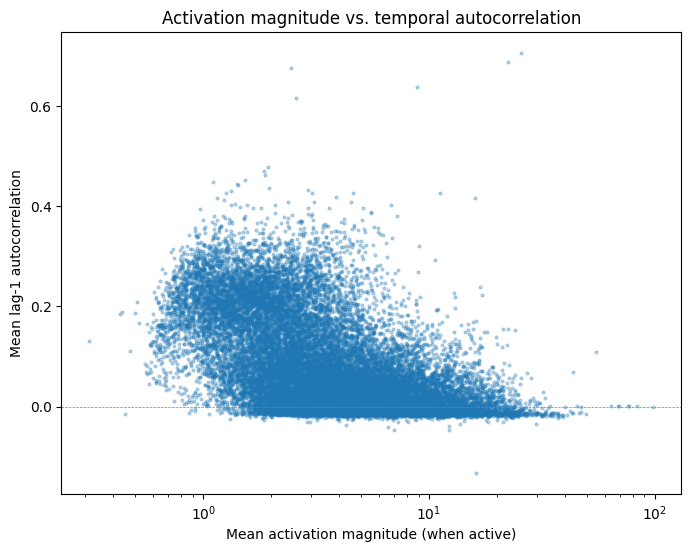

In [8]:
config.output_dir.mkdir(parents=True, exist_ok=True)

fig = plot_magnitude_vs_autocorrelation(
    stats.mean_magnitude_when_active,
    stats.mean_autocorrelation[:, 0],
    output_path=config.output_dir / "magnitude_vs_autocorrelation.png",
)
fig.show()

## Significance: Shuffled Baseline

Compute shuffled autocorrelations on a subset of sequences and overlay with real distribution.

Shuffled baseline: 100%|██████████| 1/1 [00:02<00:00,  2.47s/it]
/var/folders/cp/njcxk24s53bbd3qg6ndhkbvw0000gn/T/ipykernel_27355/498165155.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


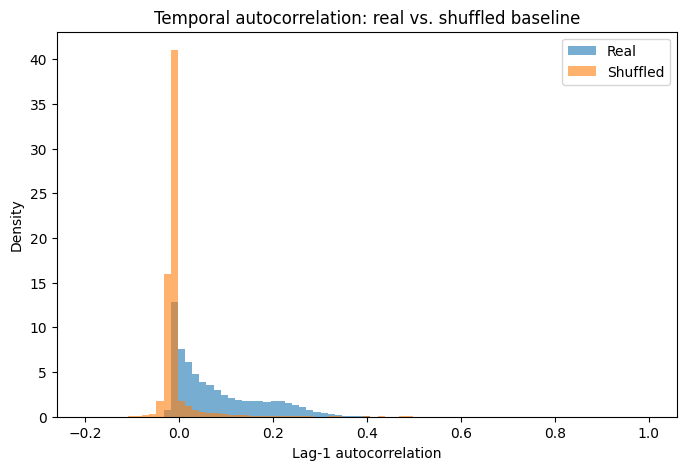

In [9]:
# Compute shuffled baseline on a few sequences
rng = np.random.default_rng(42)
num_shuffled_sequences = min(16, config.num_sequences)

shuffled_ac_sum = np.zeros((num_features, config.max_lag))
shuffled_ac_count = np.zeros((num_features, config.max_lag), dtype=np.int64)

for batch_idx in tqdm(range((num_shuffled_sequences + config.batch_size - 1) // config.batch_size), desc="Shuffled baseline"):
    start = batch_idx * config.batch_size
    end = min(start + config.batch_size, num_shuffled_sequences)
    batch_tokens = tokens[start:end].to(device)
    batch_acts = extract_sae_features_batch(model, sae, batch_tokens, config.hook_point)
    
    for i in range(batch_acts.shape[0]):
        shuf_ac = compute_shuffled_baseline(
            batch_acts[i], config.max_lag, config.min_activations_for_autocorr, rng
        )
        valid = ~np.isnan(shuf_ac)
        shuffled_ac_sum += np.where(valid, shuf_ac, 0.0)
        shuffled_ac_count += valid.astype(np.int64)

with np.errstate(divide="ignore", invalid="ignore"):
    mean_shuffled_ac = np.where(
        shuffled_ac_count > 0,
        shuffled_ac_sum / shuffled_ac_count,
        np.nan,
    )

fig = plot_autocorrelation_histogram(
    stats.mean_autocorrelation[:, 0],
    mean_shuffled_ac[:, 0],
    output_path=config.output_dir / "autocorrelation_histogram.png",
)
fig.show()

## Significance: Ljung-Box Test

Run Ljung-Box on a subset of sequences. This is slower (loops over features),
so we use a single sequence.

Running Ljung-Box test (this may take a minute)...
Features tested: 3491
Significant at p<0.01: 427 (12.2%)
Significant at p<0.05: 513 (14.7%)


/var/folders/cp/njcxk24s53bbd3qg6ndhkbvw0000gn/T/ipykernel_27355/260856906.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


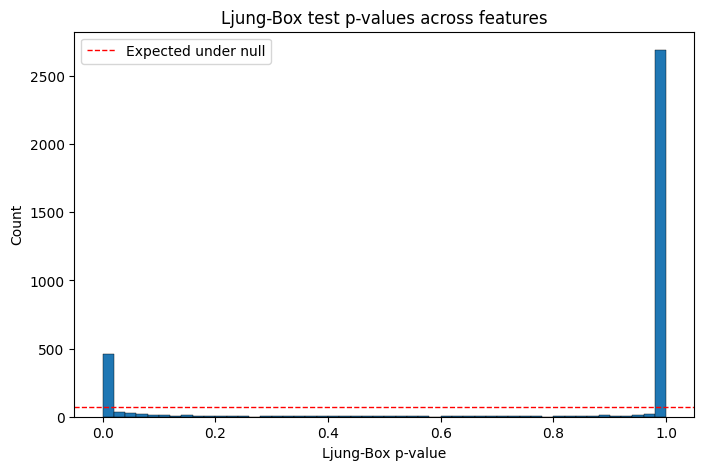

In [10]:
# Extract features for first sequence
lb_tokens = tokens[:1].to(device)
lb_acts = extract_sae_features_batch(model, sae, lb_tokens, config.hook_point)

print("Running Ljung-Box test (this may take a minute)...")
p_values = ljung_box_test(lb_acts[0], config.max_lag)

valid_p = p_values[~np.isnan(p_values)]
print(f"Features tested: {len(valid_p)}")
print(f"Significant at p<0.01: {(valid_p < 0.01).sum()} ({(valid_p < 0.01).mean()*100:.1f}%)")
print(f"Significant at p<0.05: {(valid_p < 0.05).sum()} ({(valid_p < 0.05).mean()*100:.1f}%)")

fig = plot_ljung_box_pvalues(
    p_values,
    output_path=config.output_dir / "ljung_box_pvalues.png",
)
fig.show()

## Autocorrelation Decay Curves

Show lags 1-10 for the top features by lag-1 autocorrelation.

Top 10 features by mean lag-1 autocorrelation:
  Feature 13765: lag-1 AC = 0.7060, magnitude = 25.6177, frequency = 0.0007
  Feature  4067: lag-1 AC = 0.6884, magnitude = 22.3246, frequency = 0.0007
  Feature  7451: lag-1 AC = 0.6760, magnitude = 2.4604, frequency = 0.0626
  Feature 17292: lag-1 AC = 0.6375, magnitude = 8.8173, frequency = 0.0003
  Feature 14388: lag-1 AC = 0.6165, magnitude = 2.5886, frequency = 0.0820
  Feature  3613: lag-1 AC = 0.4789, magnitude = 1.9404, frequency = 0.0367
  Feature  1602: lag-1 AC = 0.4706, magnitude = 1.8590, frequency = 0.0152
  Feature  8992: lag-1 AC = 0.4628, magnitude = 1.8762, frequency = 0.0152
  Feature 20682: lag-1 AC = 0.4526, magnitude = 1.5367, frequency = 0.0122
  Feature  6863: lag-1 AC = 0.4480, magnitude = 1.1086, frequency = 0.0450


/var/folders/cp/njcxk24s53bbd3qg6ndhkbvw0000gn/T/ipykernel_27355/2745091187.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


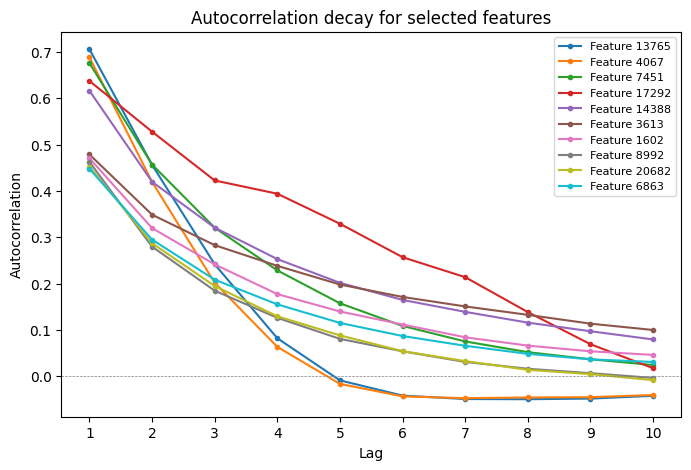

In [11]:
lag1 = stats.mean_autocorrelation[:, 0]
valid_lag1 = ~np.isnan(lag1)

# Top 10 by lag-1 AC
ranked = np.argsort(lag1[valid_lag1])[::-1]
top_feature_ids = np.where(valid_lag1)[0][ranked[:10]]

print("Top 10 features by mean lag-1 autocorrelation:")
for fid in top_feature_ids:
    print(f"  Feature {fid:5d}: lag-1 AC = {lag1[fid]:.4f}, "
          f"magnitude = {stats.mean_magnitude_when_active[fid]:.4f}, "
          f"frequency = {stats.activation_frequency[fid]:.4f}")

fig = plot_autocorrelation_decay(
    stats.mean_autocorrelation,
    top_feature_ids.tolist(),
    config.max_lag,
    output_path=config.output_dir / "autocorrelation_decay.png",
)
fig.show()

## Text Visualization

Search for sequences where the top feature has high activation, then visualize the activation pattern across tokens.

Feature 13765: best sequence = 3457 (total activation = 604.21)
Active at 17/128 positions
Text:  President Does His Job, Maybe https://t.co/uJg06zytF1 — eve peyser (@evepeyser) March 26, 2017

"don't applaud a fish for swimming" https://t.co/NhGhZBHM0C — Spencer Althouse (@SpencerAlthouse) March...


/var/folders/cp/njcxk24s53bbd3qg6ndhkbvw0000gn/T/ipykernel_27355/402980691.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


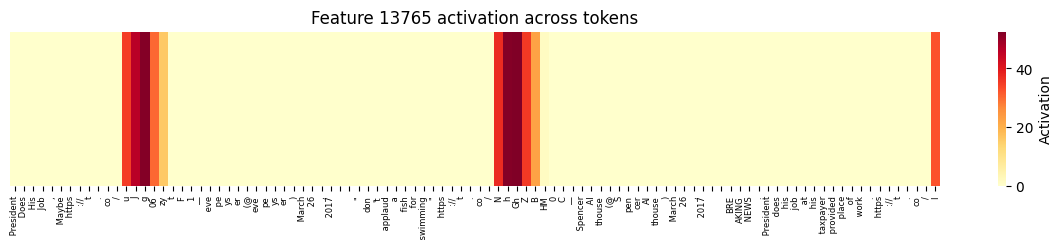

In [12]:
viz_feature = top_feature_ids[0]
seq_idx = best_seq_idx[viz_feature]

print(f"Feature {viz_feature}: best sequence = {seq_idx} (total activation = {best_total_act[viz_feature]:.2f})")

# Single forward pass for just this one sequence
viz_acts = extract_sae_features_batch(
    model, sae, tokens[seq_idx].unsqueeze(0).to(device), config.hook_point
)
token_strings = [model.tokenizer.decode(t.item()) for t in tokens[seq_idx]]

num_active = (viz_acts[0, :, viz_feature] > 0).sum()
print(f"Active at {num_active}/{config.seq_length} positions")
print(f"Text: {model.tokenizer.decode(tokens[seq_idx].tolist())[:200]}...")

fig = plot_token_activation_heatmap(
    viz_acts[0, :, viz_feature],
    token_strings,
    viz_feature,
    output_path=config.output_dir / f"token_heatmap_feature_{viz_feature}.png",
)
fig.show()

## Summary

Key numbers to report:

In [13]:
valid_ac = ~np.isnan(stats.mean_autocorrelation[:, 0])
valid_mag = ~np.isnan(stats.mean_magnitude_when_active)
both_valid = valid_ac & valid_mag

ac1 = stats.mean_autocorrelation[both_valid, 0]
mag = stats.mean_magnitude_when_active[both_valid]

print(f"Total features: {num_features}")
print(f"Features with valid AC + magnitude: {both_valid.sum()}")
print(f"")
print(f"Lag-1 autocorrelation: mean={ac1.mean():.4f}, median={np.median(ac1):.4f}")
print(f"Mean magnitude (when active): median={np.median(mag):.4f}")
print(f"")
print(f"Features with lag-1 AC > 0.5: {(ac1 > 0.5).sum()}")
print(f"Features with lag-1 AC > 0.5 AND magnitude < median: {((ac1 > 0.5) & (mag < np.median(mag))).sum()}")
print(f"")
if len(valid_p) > 0:
    print(f"Ljung-Box (single sequence): {(valid_p < 0.01).sum()}/{len(valid_p)} features significant at p<0.01")

Total features: 24576
Features with valid AC + magnitude: 24559

Lag-1 autocorrelation: mean=0.0788, median=0.0461
Mean magnitude (when active): median=3.3402

Features with lag-1 AC > 0.5: 5
Features with lag-1 AC > 0.5 AND magnitude < median: 2

Ljung-Box (single sequence): 427/3491 features significant at p<0.01
